# The 9-point report card for stocks — does it really pick winners? 📊
### Piotroski's F-Score promises to 'separate winners from losers' — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Winners_vs_losers%3F: Busted](https://img.shields.io/badge/Winners_vs_losers%3F-Busted-8b949e?style=flat-square)

There's a beloved value-investing shortcut: score every company on a **9-point checklist** of financial health — is it profitable? generating cash? cutting debt? not diluting shareholders? — and the high scorers (8-9) are supposed to **beat** the low scorers (0-1). Nine green checkmarks, a winner; a pile of red, a loser. Clean, intuitive, famous.

It's a *good idea* — and in the place it was discovered (tiny, cheap, overlooked value stocks) it genuinely works. But lift it onto a basket of household-name large caps and something quietly breaks: the 'winners' stop beating the market. This notebook shows where — and why a positive-looking number can still be nothing.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We pull real 10-K numbers from **SEC EDGAR** for a fixed basket of large/mid caps that all **survived to today** — which quietly removes the dead losers a low score would have flagged, and is *not* the small-cap value world where the F-Score's edge lives. We say so throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from piotroski_f_score import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    P = data.load_real()
    RET = P["returns"]; RET = RET[RET.index <= 2025]      # drop in-progress 2026
    FS = st.compute_fscore(P); FS = FS[FS.index <= 2024]  # fiscal y -> returns y+1<=2025
    LS = st.long_short(FS, RET)
else:
    P = RET = FS = LS = None
print("real EDGAR+price cache present:", HAVE_REAL,
      "| usable long-short years:", (0 if LS is None else len(LS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-22', 'firms': 21, 'firm_years': 249, 'mean_f': 5.54, 'fiscal_lo': 2009, 'fiscal_hi': 2024, 'ret_lo': 2010, 'ret_hi': 2025, 'n_years': 15, 'high': 14.77, 'low': 12.13, 'market': 16.37, 'hi_minus_mkt': -1.6, 'hi_minus_mkt_t': -1.38, 'spread': 2.64, 'spread_t': 0.62, 'placebo_p': 0.256, 'hit': 53, 'hit_yrs': 8, 'net': 1.74, 'net_t': 0.41, 'buckets': [('0-1', 3.21, 3), ('2-3', 10.72, 25), ('4-5', 17.38, 87), ('6-7', 17.39, 110), ('8-9', 15.73, 24)], 'robust': [(8, 3, 2, -4.64, -0.28, 0.612), (7, 3, 8, -1.38, -0.57, 0.614), (7, 4, 15, 2.64, 0.62, 0.256), (6, 4, 15, 4.48, 1.06, 0.108), (6, 5, 15, 0.94, 0.5, 0.376)], 'syn': [(0.0, 18, 10.7, 9.9, 0.86, 0.75, 0.252), (0.04, 18, 16.5, 6.5, 10.03, 8.61, 0.0), (0.1, 18, 25.2, 1.4, 23.79, 19.91, 0.0)]}


real EDGAR+price cache present: True | usable long-short years: 15


## The answer first

| Question | Answer |
|---|---|
| Do high-score firms beat low-score firms? | **A little — +2.6%/yr on average.** That's the headline 'it works.' |
| Is that gap real? | **Can't tell.** With only ~15 years it's statistically indistinguishable from picking the same number of stocks **at random** (a coin matches it ~1 time in 4). |
| Do the 'winners' beat the market? | **No.** The high-score leg earns **+14.8%/yr** — *below* the **+16.4%/yr** equal-weight basket. The tiny spread comes from the *losers* being slightly worse, not the winners being better. |
| Does a higher score always mean a higher return? | **No.** Returns climb with the score until the **6-7** bucket and then **fall** for the very best **8-9** firms. A real winner-picker doesn't do that. |

> The F-Score is a sensible *quality screen*. But on this large-cap survivor tape it does **not** separate winners from losers the way the headline promises.

## 1 · The claim

> *"Add up nine yes/no checks on a company's books — profitability, balance-sheet strength, operating efficiency. Firms scoring 8 or 9 are financially improving; firms scoring 0 or 1 are deteriorating. Buy the strong, avoid (or short) the weak, and you'll separate winners from losers."*

Joseph Piotroski introduced the F-Score in 2000. The nine points are intuitive: positive profit, positive cash flow, *improving* profitability, cash earnings that exceed paper earnings, falling debt, rising liquidity, no new share issuance, fatter margins, and more sales per dollar of assets. We'll rebuild all nine from real SEC filings and check the promise.

## 2 · So what?

Two very different claims hide inside 'it separates winners from losers,' and only one is interesting. (1) *Do good-looking companies tend to go up?* Sure — but **most** stocks go up over time, so that's nearly free. The claim that matters is (2) *do the high scorers beat a fair benchmark — the market itself — by enough to bet on?* If the 'winners' merely match (or trail) an equal-weight basket of the same stocks, the score isn't picking winners; it's along for the ride. And a screen that only works by *avoiding a few losers* is a different, weaker thing than one that *finds winners*.

## 3 · How would we even know?

We rebuild the F-Score honestly and let it pick:

1. **Score every firm, every year.** Pull the real 10-K numbers from EDGAR, compute all nine binary points, sum them 0-9.
2. **Let the score trade.** Each year, go **long** the high scorers and **short** the low scorers, and measure what they did **the next calendar year** (so we never use a report before it's filed). Compare to the equal-weight basket — the honest benchmark.
3. **Stress the luck.** Replace the score's picks with the **same number of random stocks**, thousands of times. If random picking matches the F-Score often, the 'edge' is noise.
4. **Check the ladder.** Does the return rise *all the way* from score 0 to score 9? A real winner-picker is monotone; a fluke isn't.

## 4 · The teardown — let's actually look

**First, the three legs.** The high-score 'winners,' the low-score 'losers,' and the equal-weight basket they all live in. Watch where the winners land relative to the market.

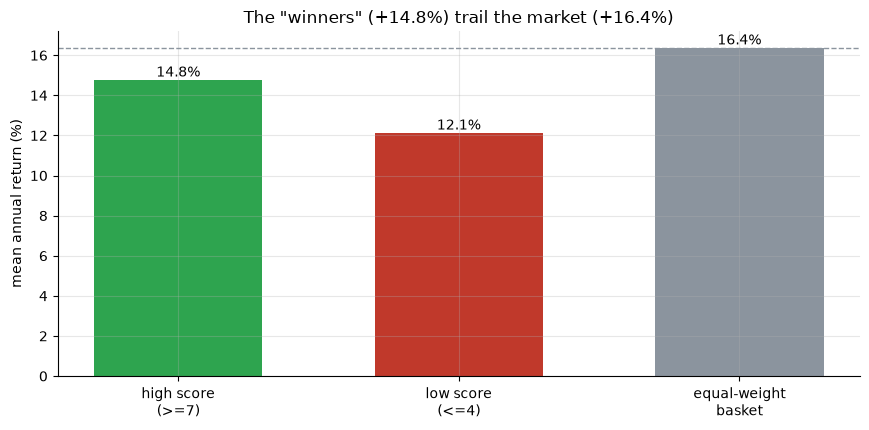

high-score leg 14.8% vs market 16.4%  -> winners trail by 1.6 pts


In [2]:
if HAVE_REAL:
    high, low, mkt = LS['high'].mean()*100, LS['low'].mean()*100, LS['market'].mean()*100
else:
    high, low, mkt = R['high'], R['low'], R['market']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
bars = ax.bar(['high score\n(>=7)', 'low score\n(<=4)', 'equal-weight\nbasket'],
              [high, low, mkt], color=[GREEN, RED, GREY], width=.6)
ax.axhline(mkt, ls='--', c=GREY, lw=1)
ax.set_ylabel('mean annual return (%)')
ax.set_title('The \"winners\" (+%.1f%%) trail the market (+%.1f%%)' % (high, mkt))
for b,v in zip(bars,[high,low,mkt]): ax.annotate(f'{v:.1f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'high-score leg {high:.1f}% vs market {mkt:.1f}%  -> winners trail by {mkt-high:.1f} pts')

There's the first crack. The high-F-score 'winners' earn **+14.8%/yr** but the equal-weight basket earns **+16.4%/yr** — the winners *trail the market*. The only reason the long-minus-short spread is positive (**+2.6%/yr**) is that the low-score leg (**+12.1%**) is a touch worse. The score isn't finding winners; it's mildly avoiding losers.

**Does a higher score always pay more?** A real winner-picker climbs the whole ladder. Here's the average next-year return for each score bucket, 0-1 up to 8-9.

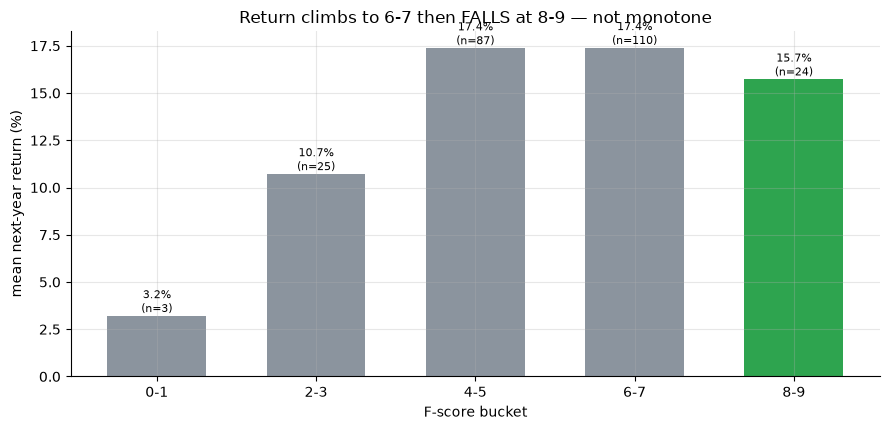

top bucket 8-9: 15.7%  vs 6-7: 17.4% -> the best firms do WORSE


In [3]:
if HAVE_REAL:
    bk = st.score_buckets(FS, RET)
    labels = list(bk.index); vals = [bk.loc[l,'mean_ret']*100 for l in labels]; ns=[int(bk.loc[l,'n']) for l in labels]
else:
    labels = [b[0] for b in R['buckets']]; vals=[b[1] for b in R['buckets']]; ns=[b[2] for b in R['buckets']]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
colors = [GREEN if i==len(vals)-1 else GREY for i in range(len(vals))]
bars = ax.bar(labels, vals, color=colors, width=.62)
ax.set_xlabel('F-score bucket'); ax.set_ylabel('mean next-year return (%)')
ax.set_title('Return climbs to 6-7 then FALLS at 8-9 — not monotone')
for b,v,nn in zip(bars,vals,ns): ax.annotate(f'{v:.1f}%\n(n={nn})',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
print('top bucket 8-9:', f'{vals[-1]:.1f}%', ' vs 6-7:', f'{vals[-2]:.1f}%', '-> the best firms do WORSE')

The ladder rises — and then trips. The **6-7** bucket returns **17.4%**, but the very-best **8-9** firms return only **15.7%**. A genuine 'separate winners from losers' factor climbs monotonically to the top; a non-monotone ladder is the signature of noise in a thin top bucket (just 24 firm-years up there).

**Could random stock-picking match it?** The honest test: replace the F-Score's picks with the *same number* of random stocks, thousands of times, and see where the real spread lands in the cloud of luck.

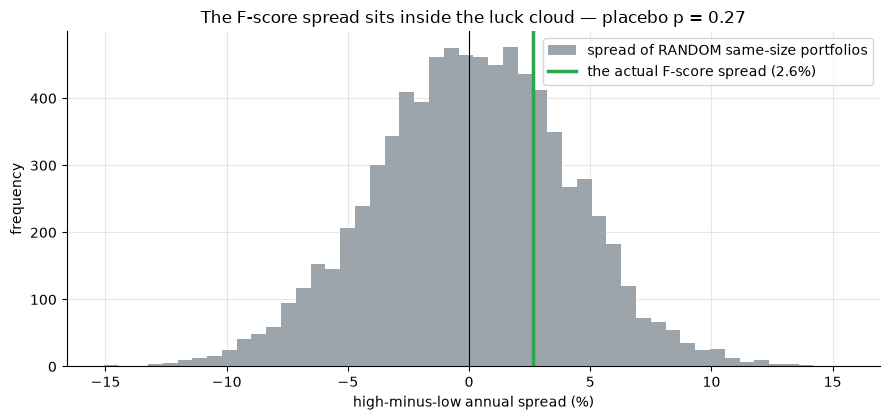

random picking matches or beats the F-score 27% of the time


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(FS, RET, n_draws=8000)
    obs = pl['obs_spread']*100; pval = pl['p_value']
    # rebuild the random-spread cloud for the picture
    years=[]
    for y in LS.index:
        s = FS.loc[y].dropna(); nxt = RET.loc[int(y)+1].dropna(); s,nxt = s.align(nxt,join='inner')
        years.append((nxt.to_numpy(), int(LS.loc[y,'n_hi']), int(LS.loc[y,'n_lo'])))
    rng = np.random.default_rng(362)
    draws=[]
    for _ in range(8000):
        sp=[]
        for arr,nh,nl in years:
            idx=rng.permutation(len(arr)); sp.append(arr[idx[:nh]].mean()-arr[idx[nh:nh+nl]].mean())
        draws.append(np.mean(sp))
    draws=np.array(draws)*100
else:
    obs = R['spread']; pval = R['placebo_p']
    rng = np.random.default_rng(362); draws = rng.normal(0, 4.0, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='spread of RANDOM same-size portfolios')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual F-score spread ({obs:.1f}%)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('high-minus-low annual spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The F-score spread sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'random picking matches or beats the F-score {pval*100:.0f}% of the time')

The green line — the real F-Score spread — sits **inside** the grey cloud of random portfolios. About **25%** of random same-size picks do as well or better. In plain terms: **on this tape, the nine-point checklist barely outpicks a dartboard.**

## 5 · The verdict

- **Signal — Weak.** The high-minus-low spread is positive (**+2.6%/yr**) but isn't statistically distinguishable from random picking, the 'winners' trail the market, and the score isn't monotone. Real in its home universe (small-cap deep value), weak here.
- **Tradability — Mirage.** Net of trading costs and short-borrow the spread is **+1.7%/yr** — and the long leg lags the basket. Nothing to deploy.
- **"Winners vs losers"? — Busted.** On a large-cap survivor basket the score sidesteps a thin tail of losers; it does not pick winners. A useful health check, not a money machine.

## 6 · Could you actually trade it? — costs and the missing losers

Two practical problems on top of the weak signal. First, you'd **short** the low-score firms — which costs **borrow**, and the very firms a low score flags are the hard-to-borrow ones. Second, our basket only contains firms that **survived** — the spectacular low-score blow-ups that *should* make the short leg pay aren't even in the data.

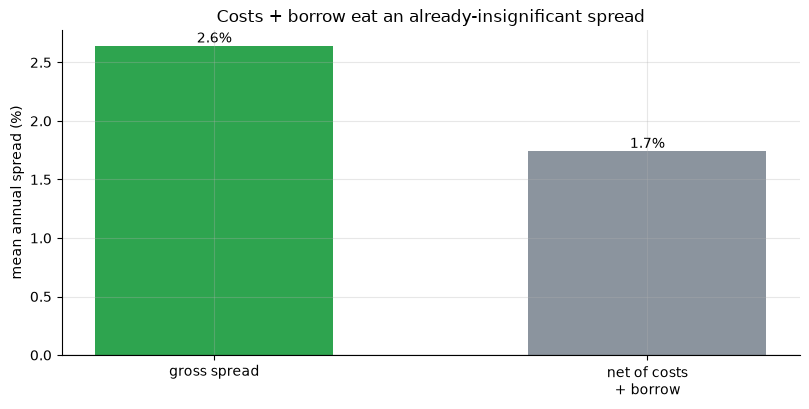

gross 2.6% -> net 1.7% after one-way costs x turnover + short borrow


In [5]:
if HAVE_REAL:
    s = st.summarize(FS, RET); gross = s['gross_mean']*100; net = s['net_mean']*100
else:
    gross = R['spread']; net = R['net']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
bars = ax.bar(['gross spread', 'net of costs\n+ borrow'], [gross, net], color=[GREEN, GREY], width=.55)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean annual spread (%)')
ax.set_title('Costs + borrow eat an already-insignificant spread')
for b,v in zip(bars,[gross,net]): ax.annotate(f'{v:.1f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'gross {gross:.1f}% -> net {net:.1f}% after one-way costs x turnover + short borrow')

Gross **+2.6%/yr** becomes net **+1.7%/yr** — and remember it was never significant to begin with. Worse, the survivorship that's missing here would only *hurt* a live version more (your shorts would include names too risky to borrow). The honest read isn't 'a small edge after costs' — it's 'no edge you could bank.'

## 7 · Going further 🚪

- **Run it where it lives.** Piotroski's edge is documented among **small, cheap, low-coverage value** stocks. Swap our large-cap basket for a small-cap *value* universe and the spread should reappear — the lesson here is about **universe**, not the checklist.
- **The growth-side twin.** [Study 232 — Mohanram G-Score](../../232-mohanram-g-score/) is the same financial-statement-analysis idea aimed at *growth* (low book-to-market) firms.
- **Sibling screens.** [Study 121 — Magic-Formula](../../121-magic-formula/) and [Study 122 — Gross-Profitability](../../122-gross-profitability/) run on the same EDGAR machinery — how much does a nine-point composite add over one good ratio?

*Think the F-Score beats the market by more than luck on large caps? Capture the events, draw the same number of random portfolios, and show the spread landing **outside** the cloud — then we'll talk.*